## Import libraries and data

In [31]:
import pandas as pd
import geopandas as gpd
import networkx as nx
from Tool import clean_speed, fill_tracks, clean_elec

## Inputs

In [5]:
rail_data = "data/uk_railways_osm.gpkg"

## Import of the datasets and conversion into a csv file

In [6]:
# 1. Chargement du fichier
gdf = gpd.read_file(rail_data)

# 2. Conservation de la géométrie
# On transforme la géométrie en format WKT (Well-Known Text).
# C'est un format texte que le CSV accepte et qui contient tous les points GPS.
# Exemple : "LINESTRING (-1.81 52.57, -1.81 52.56)"
gdf['geometry_wkt'] = gdf['geometry'].apply(lambda x: x.wkt)

# 3. Extraction des coordonnées de départ et d'arrivée (pour tes noeuds/jonctions)
# C'est très utile pour tes futurs calculs de graphe dans Excel
gdf['start_lon'] = gdf['geometry'].apply(lambda x: x.coords[0][0])
gdf['start_lat'] = gdf['geometry'].apply(lambda x: x.coords[0][1])
gdf['end_lon'] = gdf['geometry'].apply(lambda x: x.coords[-1][0])
gdf['end_lat'] = gdf['geometry'].apply(lambda x: x.coords[-1][1])

# 4. Nettoyage de la colonne 'other_tags'
# Dans OSM, cette colonne contient souvent des données clés sous forme de texte 
# (ex: "gauge"=>"1435"). On va la garder telle quelle, mais assure-toi qu'elle est bien lue.
if 'other_tags' in gdf.columns:
    gdf['other_tags'] = gdf['other_tags'].astype(str)

# 5. Suppression de la colonne géométrie originale (non compatible CSV)
df_rail = pd.DataFrame(gdf.drop(columns=['geometry']))

# 6. Export en CSV
# J'utilise le séparateur ";" car les noms de gares contiennent souvent des virgules ","
df_rail.to_csv("complete_railway_network.csv", index=False, sep=';', encoding='utf-8')

print(f"Export terminé ! {len(df_rail)} lignes exportées.")

Export terminé ! 138272 lignes exportées.


In [7]:
df_rail.head()

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,usage,electrified,...,surface,width,bicycle,z_order,other_tags,geometry_wkt,start_lon,start_lat,end_lon,end_lat
0,740,Cross-City Line,None,None,None,None,None,rail,branch,contact_line,...,None,None,None,5,"""operator:wikidata""=>""Q1501071""","LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950
1,2148,Cross-City Line,None,None,None,None,None,rail,branch,contact_line,...,None,None,None,15,"""level""=>""1"",""operator:wikidata""=>""Q1501071""","LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113
2,2256,None,cycleway,None,None,None,None,abandoned,None,None,...,asphalt,None,None,5,None,"LINESTRING (-3.3738363 50.6268921, -3.372792 5...",-3.373836,50.626892,-3.360636,50.629226
3,3413,North Clyde Line,None,None,None,None,None,rail,main,contact_line,...,None,None,None,5,"""operator:wikidata""=>""Q1501071""","LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447
4,3417,North Clyde Line,None,None,None,None,None,rail,main,contact_line,...,None,None,None,5,"""operator:wikidata""=>""Q1501071""","LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938


## Cleaning of the dataset

### Selection of only national Railway parts

In [8]:
# Selection of only usable national Railway parts
df_rail = df_rail[df_rail['railway'] == 'rail']
df_rail = df_rail[df_rail['usage'].isin(['main', 'branch', 'industrial', 'none', None])]

In [9]:
len(df_rail)

87186

Clean speed format and fill missing values with 60 mph.

In [10]:
df_rail = clean_speed(df_rail)

## Fill the missing values in terms of track numbers

Here, we consider to fill the branch or industrial types with 1 track, the others with 2 tracks.

In [11]:
df_rail = fill_tracks(df_rail)

We will simplify different type of electrification

In [12]:
df_rail['elec_type'] = df_rail.apply(clean_elec, axis=1)

In [19]:
df_rail.columns

Index(['osm_id', 'name', 'railway', 'usage', 'electrified', 'frequency',
       'gauge', 'maxspeed', 'operator', 'voltage', 'tracks', 'passenger_lines',
       'geometry_wkt', 'start_lon', 'start_lat', 'end_lon', 'end_lat',
       'elec_type'],
      dtype='object')

In [14]:
to_drop = [
    "highway", "waterway", "aerialway", "barrier", "man_made",
    "railway_aws", "railway_tpws", "ref", "layer", "foot", "lit",
    "segregated", "smoothness", "surface", "width", "bicycle",
    "z_order", "other_tags"
]

df_rail = df_rail.drop(columns=[c for c in to_drop if c in df_rail.columns])

In [15]:
# Affiche chaque valeur unique une seule fois
print("Valeurs uniques dans 'electrified':")
print(df_rail['electrified'].unique())

# Affiche le nombre d'apparitions de chaque valeur (très utile pour voir les erreurs)
print("\nStatistiques de la colonne 'electrified':")
print(df_rail['electrified'].value_counts(dropna=False))

Valeurs uniques dans 'electrified':
['contact_line' 'no' 'rail' None 'proposed' '4th_rail' 'contact_line;rail'
 'contact_line;4th_rail' '0' 'yes' 'construction']

Statistiques de la colonne 'electrified':
electrified
no                       41684
contact_line             26816
rail                     13066
None                      4929
4th_rail                   280
proposed                   242
contact_line;rail          157
contact_line;4th_rail        9
0                            1
yes                          1
construction                 1
Name: count, dtype: int64


In [16]:
df_rail.head()

,osm_id,name,railway,usage,electrified,frequency,gauge,maxspeed,operator,voltage,tracks,passenger_lines,geometry_wkt,start_lon,start_lat,end_lon,end_lat,elec_type
0,740,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.8178905 52.5700974, -1.8179287 ...",-1.817891,52.570097,-1.822176,52.565950,Overhead
1,2148,Cross-City Line,rail,branch,contact_line,50,1435,45.0,Network Rail,25000,1,None,"LINESTRING (-1.873028 52.5054182, -1.8726964 5...",-1.873028,52.505418,-1.871725,52.504113,Overhead
3,3413,North Clyde Line,rail,main,contact_line,50,1435,50.0,Network Rail,25000,2,2,"LINESTRING (-4.3258776 55.8827209, -4.3255873 ...",-4.325878,55.882721,-4.323074,55.882447,Overhead
4,3417,North Clyde Line,rail,main,contact_line,50,1435,40.0,Network Rail,25000,2,2,"LINESTRING (-4.3138852 55.8776742, -4.3139865 ...",-4.313885,55.877674,-4.310577,55.870938,Overhead
5,3471,Midland Main Line,rail,main,contact_line,50,1435,90.0,Network Rail,25000,1,4,"LINESTRING (-0.4950811 51.9681192, -0.4951938 ...",-0.495081,51.968119,-0.495194,51.963738,Overhead


In [17]:
print("Valeurs uniques dans 'Operator:")
print(df_rail['operator'].unique())

Valeurs uniques dans 'Operator:
['Network Rail' 'Transport for London' 'South Western Railway'
 'Swanage Railway' None 'HS1 Ltd' 'Severn Valley Railway' 'Southern GTR'
 'London Overground' 'Great Central Railway' 'East Lancashire Railway'
 'Dartmouth Steam Railway' 'Bluebell Railway' 'Transport for Wales'
 'Isle of Wight Steam Railway' 'Nene Valley Railway' 'Railtrack'
 'Translink NI Railways' 'Beamish Museum' 'GetLink' 'Mid Hants Railway'
 'Avon Valley Railway' 'London Underground' 'Wensleydale Railway'
 'Mid-Norfolk Railway' 'Scottish Railway Preservation Society' 'Peak Rail'
 'South Devon Railway' 'Didcot Railway Centre' 'Heathrow Airport Holdings'
 'Ecclesbourne Valley Railway' 'GBRf' 'Kent and East Sussex Railway'
 'Strathspey Railway' 'Caledonian Railway (Brechin)'
 'Chinnor and Princes Risborough Railway' 'Middleton Railway'
 'Plym Valley Railway' 'Bodmin & Wenford Railway' 'Nexus'
 'Colne Valley Railway' 'Keighley & Worth Valley Railway'
 'Weardale Railway' 'East Kent Railway'


In [18]:
len(df_rail)

87186

In [22]:
df_rail = df_rail.drop_duplicates(subset=["start_lon", "start_lat", "end_lon", "end_lat"])


In [23]:
len(df_rail)

87095

In [24]:
df_rail = df_rail[~df_rail["usage"].isin(["industrial", "military"])]


In [25]:
len(df_rail)

85565

# Graph creation

In [48]:
G = nx.Graph()

for _, row in df_rail.iterrows():
    start = (row.start_lon, row.start_lat)
    end = (row.end_lon, row.end_lat)
    G.add_edge(start, end)


In [49]:
components = list(nx.connected_components(G))
print("Nombre de composantes :", len(components))


Nombre de composantes : 12646


In [50]:
largest = max(components, key=len)
print("Taille de la plus grande composante :", len(largest))


Taille de la plus grande composante : 61871


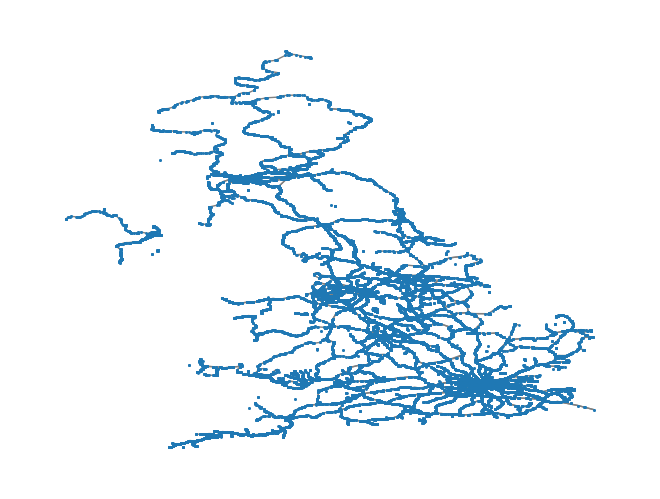

In [59]:
pos = {node: (node[0], node[1]) for node in G.nodes()}
nx.draw(G, pos, node_size=1, edge_color="gray")


In [52]:
#Quick diagnostic
nodes_with_edges = G.number_of_nodes()
print("===== Network diagnostic ===== \n")
print(f"Number of edges : {G.number_of_edges()}")
print(f"Number of connected nodes : {G.number_of_nodes()}")

#Connectivity checks

if nx.is_connected(G):
    print("Network is fully connected.")
else:
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    giant_size = len(components[0])
    print(f"Network fragmented in {len(components)} parts.")
    print(f"Giant Component : {giant_size} nodes")
    print(f"Coverage ratio : {(giant_size / nodes_with_edges)*100:.1f}%")

===== Network diagnostic ===== 

Number of edges : 85509
Number of connected nodes : 96386
Network fragmented in 12646 parts.
Giant Component : 61871 nodes
Coverage ratio : 64.2%


In [39]:
sizes = sorted([len(c) for c in components], reverse=True)
print(sizes[:20])


[61871, 742, 529, 152, 128, 101, 98, 83, 60, 53, 52, 50, 49, 48, 47, 45, 45, 44, 44, 44]


In [47]:
df_rail = df_rail[~((df_rail.start_lon == df_rail.end_lon) & (df_rail.start_lat == df_rail.end_lat))]



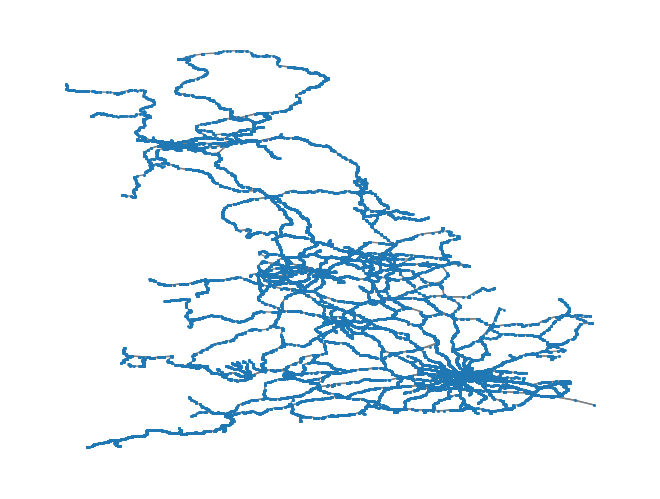

In [58]:
#Création d'un autre graphe avec le giant component uniquement
components = list(nx.connected_components(G))
giant = max(components, key=len)

G_giant = G.subgraph(giant).copy()
df_giant = df_rail[
    df_rail.apply(
        lambda r: (r.start_lon, r.start_lat) in giant
               and (r.end_lon, r.end_lat) in giant,
        axis=1
    )
].copy()

pos_giant = {node: (node[0], node[1]) for node in G_giant.nodes()}
nx.draw(G_giant, pos_giant, node_size=1, edge_color="gray")

In [56]:
print("Original nodes :", G.number_of_nodes())
print("Original edges :", G.number_of_edges())

print("Giant nodes :", G_giant.number_of_nodes())
print("Giant edges :", G_giant.number_of_edges())

ratio_nodes = G_giant.number_of_nodes() / G.number_of_nodes() * 100
ratio_edges = G_giant.number_of_edges() / G.number_of_edges() * 100

print(f"Node coverage : {ratio_nodes:.1f}%")
print(f"Edge coverage : {ratio_edges:.1f}%")


Original nodes : 96386
Original edges : 85509
Giant nodes : 61871
Giant edges : 63602
Node coverage : 64.2%
Edge coverage : 74.4%


In [57]:
print("Original components :", nx.number_connected_components(G))
print("Giant components :", nx.number_connected_components(G_giant))


Original components : 12646
Giant components : 1


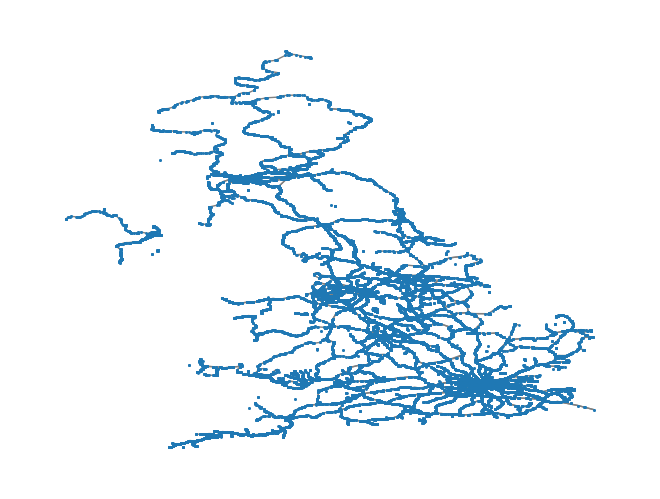

In [62]:
pos = {node: (node[0], node[1]) for node in G.nodes()}
nx.draw(G, pos, node_size=1, edge_color="gray")

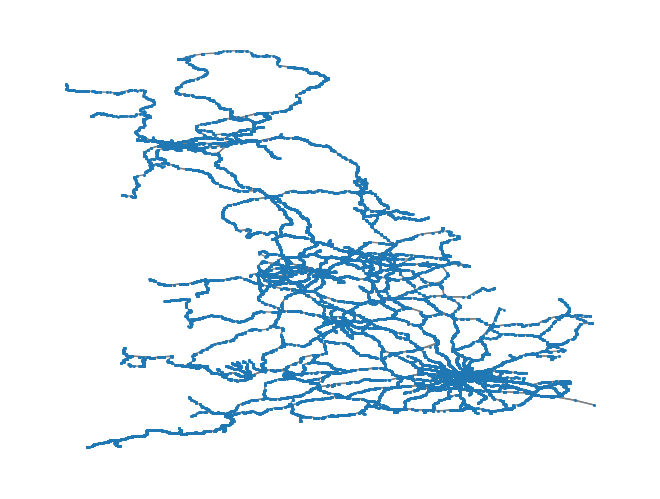

In [63]:
pos_giant = {node: (node[0], node[1]) for node in G_giant.nodes()}
nx.draw(G_giant, pos_giant, node_size=1, edge_color="gray")